## Sintisajzer

In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from scipy.fft import fft , fftfreq 
from scipy.signal import butter, lfilter, freqz
import soundfile as sf
from scipy import signal
import sounddevice as sd

In [2]:
y, sr = librosa.load('C_Major_Piano.mp3', sr=44100)

Text(22.097222222222214, 0.5, 'Amplitude')

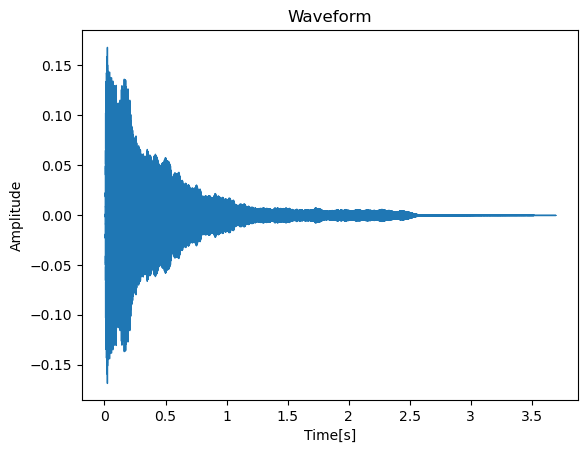

In [3]:
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.xlabel("Time[s]")
plt.ylabel("Amplitude")

In [4]:
sd.play(y, sr)
status = sd.wait()

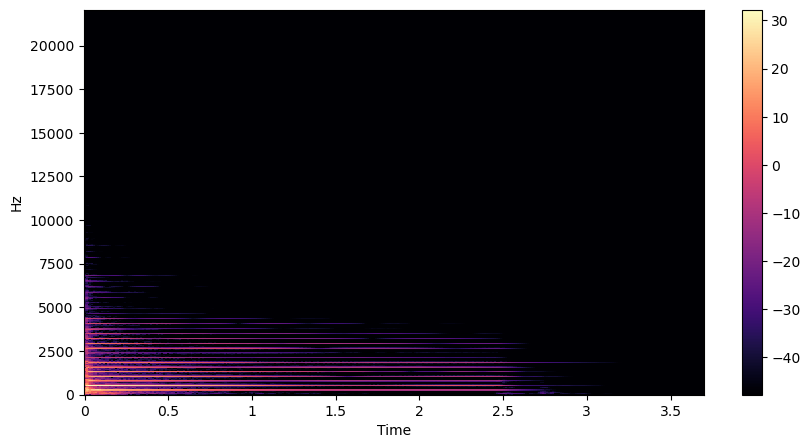

In [5]:
X = librosa.stft(y)
Xdb = librosa.amplitude_to_db(abs(X))
plt.figure(figsize = (10, 5))
librosa.display.specshow(Xdb, sr = sr, x_axis = 'time', y_axis = 'hz')
plt.colorbar()

In [6]:
a = input()

n=0

A = a[0]
B = int(a[1])

M = [['C', 1], ['C#', 2], ['D', 3], ['D#', 4], ['E', 5], ['F', 6], ['F#', 7], ['G', 8], ['G#', 9], ['A', 10], ['A#', 11], ['H', 12]]

for i in range(12):
    if A==M[i][0]:
        n = i


req_shift = (B-4)*12 + M[n][1]-1

y_shifted = librosa.effects.pitch_shift(y, sr=sr, n_steps=req_shift)
ipd.Audio(y_shifted, rate=sr)

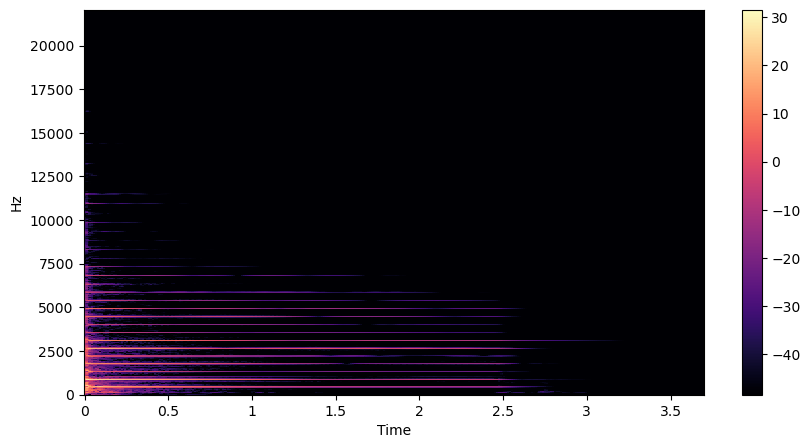

In [7]:
X = librosa.stft(y_shifted)
Xdb = librosa.amplitude_to_db(abs(X))
plt.figure(figsize = (10, 5))
librosa.display.specshow(Xdb, sr = sr, x_axis = 'time', y_axis = 'hz')
plt.colorbar()

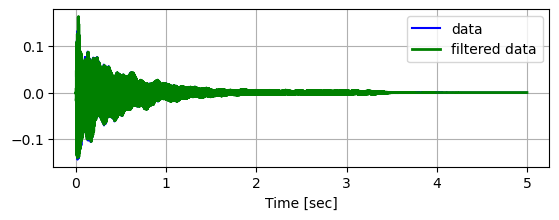

In [8]:
def butter_lowpass(cutoff, fs, order=5):
    return butter(order, cutoff, fs=fs, btype='low', analog=False)

def butter_lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = lfilter(b, a, data)
    return y

order = 6
fs = sr     
cutoff = 4500 

T = 5.0        
n = len(y)
t = np.linspace(0, T, n, endpoint=False)
data = y_shifted


pl = butter_lowpass_filter(data, cutoff, fs, order)

plt.subplot(2, 1, 2)
plt.plot(t, data, 'b-', label='data')
plt.plot(t, pl, 'g-', linewidth=2, label='filtered data')
plt.xlabel('Time [sec]')
plt.grid()
plt.legend()

plt.subplots_adjust(hspace=0.35)
plt.show()


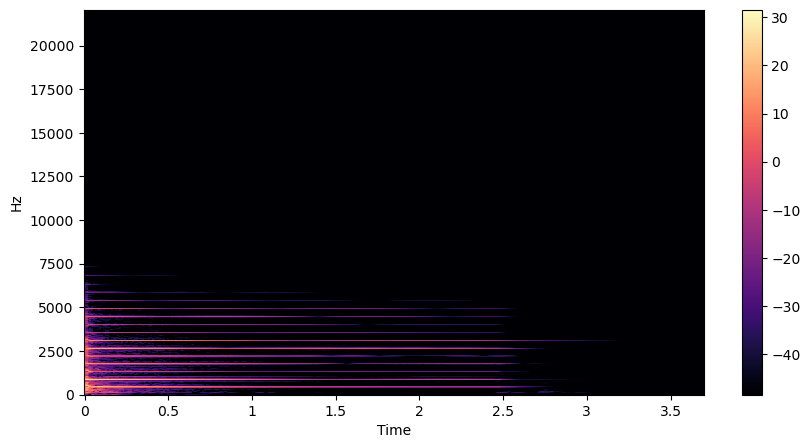

In [9]:
X = librosa.stft(pl)
Xdb = librosa.amplitude_to_db(abs(X))
plt.figure(figsize = (10, 5))
librosa.display.specshow(Xdb, sr = sr, x_axis = 'time', y_axis = 'hz')
plt.colorbar() 

In [10]:
sd.play(pl, sr)
status = sd.wait()

In [16]:
import soundfile as sf
sf.write('Output_Note.mp3', pl, sr)